In [1]:
import os
import mat73
import pandas as pd
import numpy as np
import sys
import json
import pickle
sys.path.append("..")
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
from scipy.spatial import cKDTree
import scipy
from nilearn import plotting
from src.decomposition import CompoThr
from src.setting import GetInfo, PROJECT_PATH
from src.config import COL_REG, col_pc

from sklearn.cross_decomposition import CCA
from scipy.linalg import subspace_angles

import nibabel as nib
from nilearn import datasets
from nilearn.image import load_img
from sklearn.manifold import Isomap, LocallyLinearEmbedding, MDS, SpectralEmbedding, TSNE

from utils import get_region_label, mask_meg, match_meg, update_COL_REG, get_meg_data

In [40]:
ieeg_datapath = 'ieeg_shortWOBS_fs250'
meg_datapath = '/projects/MINDLAB2025_MEG-Auditory_Cognitive_Maps/scratch/APR2020_Block3_SingleTrial_BarbaraNikita'
meg_outpath ='MEG/dataMEG'

os.path.isdir(meg_datapath)
meg_subj_list = [file.replace('_sensor.p', '') for file in os.listdir(meg_outpath) if '_sensor' in file]
print('MEG Subject number : ', len(meg_subj_list))

ieeg_subj_list = [file.replace('_epochs.p', '') for file in os.listdir(ieeg_datapath) if file[-len('epochs.p'):] == 'epochs.p']
print('iEEG Subject number : ', len(ieeg_subj_list))

info_file = ieeg_datapath + f'/{ieeg_subj_list[0]}_info.json'
with open(info_file) as json_data:
    d = json.load(json_data)
    time_ieeg = d['time_epoch']

project_path = '../' + PROJECT_PATH
coord, areas, elect_list, subj_list, regions_ieeg = GetInfo(ieeg_subj_list, data_path=ieeg_datapath, project_path=project_path)
coord=np.array(coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = np.where(abs(coord) >100, coord/1000, coord)
coord = coord/1000

out_path = 'out/data'

with open(out_path + '/ieeg_data_mean.p', "rb") as f:
    ieeg_data = pickle.load(f)
with open(out_path + '/meg_data_source.p', "rb") as f:
    meg_data = pickle.load(f)  
with open(out_path + '/data_matched.p', "rb") as f:
    data_matched = pickle.load(f)      

pos = pd.read_csv('/users/barbara/Desktop/MIB_iEEG/iEEGvsMEG/MEG/dataMEG/SUBJ_0002_pos.csv').drop(columns='Unnamed: 0')
regions_meg = get_region_label(pos)

all_regions = sorted(set(regions_meg) | set(regions_ieeg))
COL_REG = update_COL_REG(col_reg=COL_REG,all_regions=all_regions)


MEG Subject number :  32
iEEG Subject number :  30


[fetch_atlas_aal] Dataset found in /users/barbara/nilearn_data/aal_SPM12

In [28]:
label_data = 'source_avg'

In [31]:
ieeg_scaled = ieeg_data.mean(0)
meg_scaled =meg_data.mean(0).mean(0)

In [32]:
# get labels
out_path = f'out/manifolds/manifolds_{label_data}'
with open(out_path + '/Z_joint_space.p', "rb") as f:
    Z_joint_space = pickle.load(f)  

with open(out_path + '/Z_joint_time.p', "rb") as f:
    Z_joint_time = pickle.load(f)  

In [33]:
df_label_meg  =pd.read_csv(f'out/labels/labels_Kmean_MEG_{label_data}_pc.csv')
df_label_ieeg  =pd.read_csv(f'out/labels/labels_Kmean_singlePC3.csv')


In [34]:
algorithms=Z_joint_space.keys()
# pca labels
pca = PCA(3)
trans_ieeg = pca.fit_transform(ieeg_scaled.T)
trans_meg = pca.fit_transform(meg_scaled.T)

Text(0, 0.5, 'MEG colored PC1 MEG')

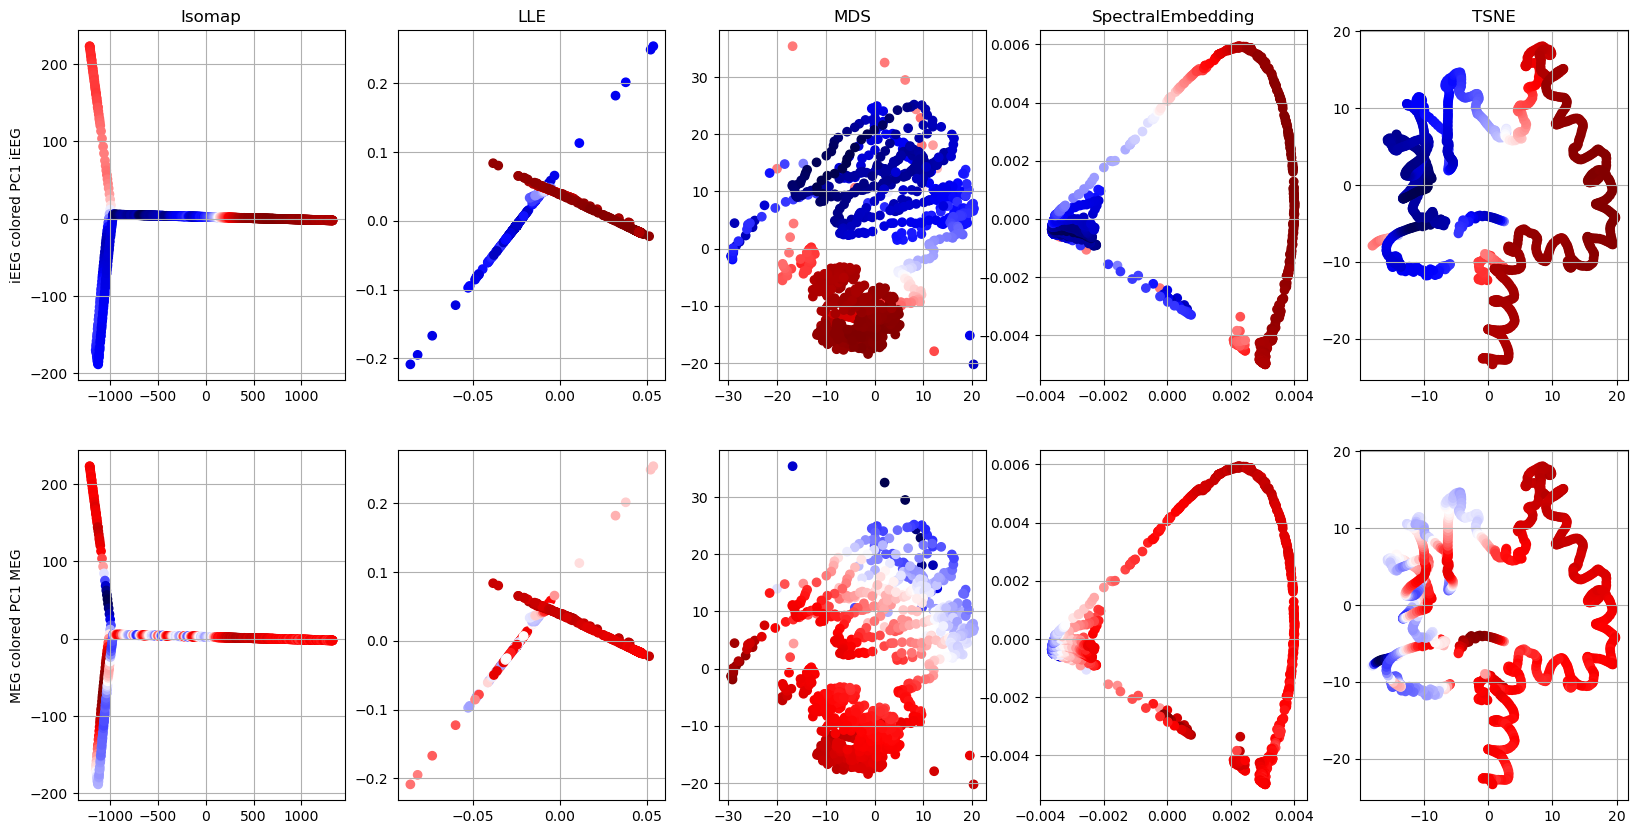

In [35]:
fig, ax=plt.subplots(2, len(algorithms), figsize=(20, 10))

for i, algo in enumerate(list(algorithms)):
    ax[0][i].set_title(algo)
    ax[0][i].scatter(Z_joint_time[algo][:, 0], Z_joint_time[algo][:, 1], c=trans_ieeg[:, 0], cmap='seismic')
    ax[1][i].scatter(Z_joint_time[algo][:, 0], Z_joint_time[algo][:, 1], c=trans_meg[:, 0], cmap='seismic')

for a in ax.flatten():
    a.grid()

ax[0][0].set_ylabel('iEEG colored PC1 iEEG')
ax[1][0].set_ylabel('MEG colored PC1 MEG')

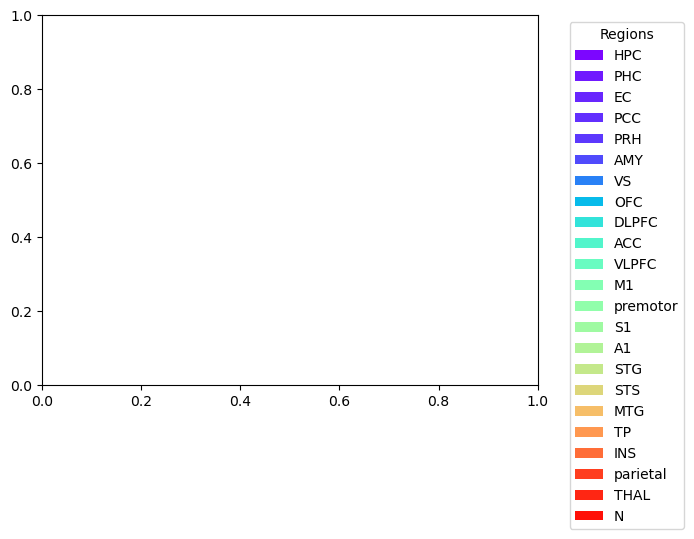

In [25]:
from matplotlib.patches import Patch

legend_elements = []
start = 0
for region in COL_REG.keys():
    n_region = sum(r == region for r in regions_ieeg)
    if n_region > 0:
        region_color = gradient[start + n_region // 2]
        legend_elements.append(Patch(facecolor=region_color,label=region))
    start += n_region

plt.legend(handles=legend_elements,title="Regions",bbox_to_anchor=(1.05, 1),loc="upper left")

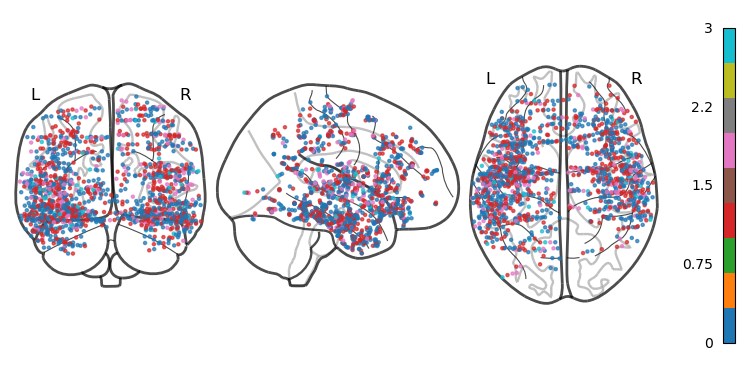

In [26]:
gradient = plt.cm.rainbow(np.linspace(0, 1, ieeg_scaled.shape[0]))
sorted_idx = np.argsort(np.linalg.norm(coord, axis=1)) 
#sorted_idx = [r_ord for region in list(COL_REG.keys()) for r_ord, r in enumerate(regions_ieeg) if r == region]
region_all_sorted=np.array(regions_ieeg)[sorted_idx]
selected_reg = np.where(region_all_sorted == 'A1', True, False)

#plotting.plot_markers(np.linspace(0, 1, ieeg_scaled.shape[0]), coord[sorted_idx]*1000,node_cmap='rainbow') #rainbow
#plotting.plot_markers(np.ones(ieeg_scaled.shape[0])[selected_reg], coord[sorted_idx][selected_reg]*1000, node_size=5)

selected_reg = np.where(df_label_ieeg['ieeg_pc2'] != 0, True, False)
size_node = np.where(df_label_ieeg['ieeg_pc2'] != 0, np.ones((len(df_label_ieeg)))*5, np.ones((len(df_label_ieeg)))*0.0001)
plotting.plot_markers(df_label_ieeg['ieeg_pc2'][sorted_idx], coord[sorted_idx]*1000, node_size=size_node,node_cmap='tab10')

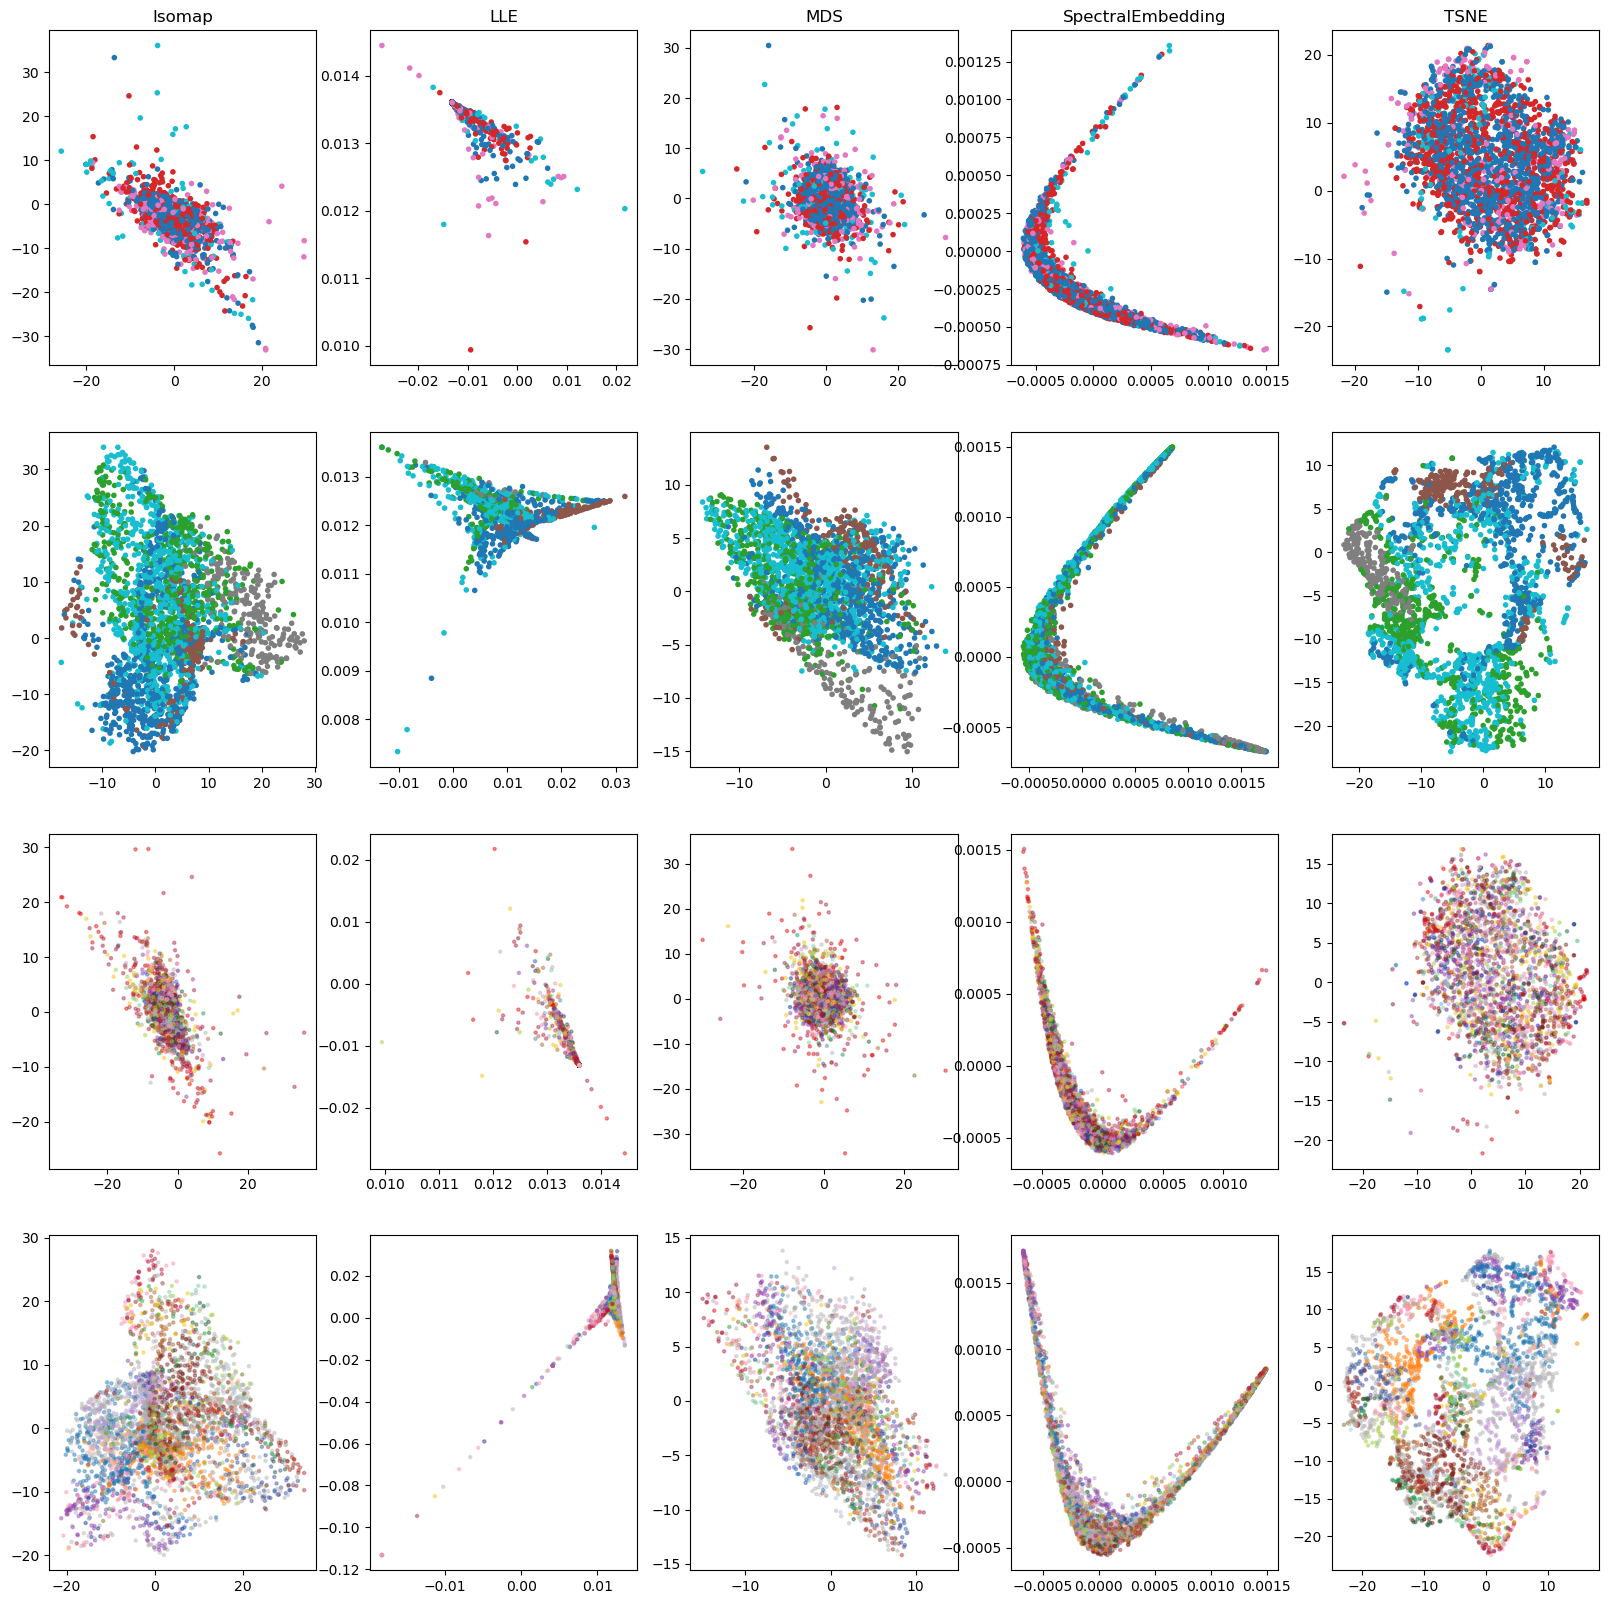

In [45]:
fig, ax=plt.subplots(4, len(Z_joint_space.keys()), figsize=(20, 20)) #, sharex='col', sharey='col')

for i, algo in enumerate(list(Z_joint_space.keys())):
    ax[0][i].set_title(algo)
    data_ieeg_embb = Z_joint_space[algo][:ieeg_scaled.shape[0], :]
    data_ieeg_embb_sorted = data_ieeg_embb[sorted_idx]#[selected_reg]
    data_meg_embb = Z_joint_space[algo][ieeg_scaled.shape[0]:, :]
    data_meg_embb_sorted = data_meg_embb[sorted_idx]#[selected_reg]
    
    ax[0][i].scatter(data_ieeg_embb_sorted[:, 1], data_ieeg_embb_sorted[:,0],c=df_label_ieeg['ieeg_pc2'][sorted_idx], s=9, alpha = 1, cmap='tab10') # c= ['pink']*len(regions_ieeg) or df_label['iEEG_PC3'][sorted_idx]
    ax[1][i].scatter(data_meg_embb_sorted[:, 1], data_meg_embb_sorted[:, 0],c=df_label_meg['meg_pc2'][sorted_idx],  s=9, alpha = 1, cmap='tab10') # c= ['green']*len(regions_ieeg) or df_label['MEG_PC3'][sorted_idx]

    df = pd.DataFrame(Z_joint_space[algo][:ieeg_scaled.shape[0], :])
    df['regions']= regions_ieeg
    mean_ = df.groupby('regions').mean()
    reg = list(df.groupby('regions').mean().index)

    ax[2][i].scatter(Z_joint_space[algo][:ieeg_scaled.shape[0], :][:, 0], Z_joint_space[algo][:ieeg_scaled.shape[0], :][:, 1], c= [COL_REG[r] for r in regions_ieeg], s=5, alpha = 0.4)

    df = pd.DataFrame(Z_joint_space[algo][ieeg_scaled.shape[0]:, :])
    df['regions']= regions_meg 
    mean_ = df.groupby('regions').mean()
    reg = list(df.groupby('regions').mean().index)

    ax[3][i].scatter(Z_joint_space[algo][ieeg_scaled.shape[0]:, :][:, 0], Z_joint_space[algo][ieeg_scaled.shape[0]:, :][:, 1], c= [COL_REG[r] for r in regions_meg], s=5, alpha = 0.4)
